# Reading FC Half by Half Performance Analysis

This Analysis showcases how Reading FC's performance has differed from the 1st Half to 2nd Half. 

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('../../../../data/rfc_matchdata.csv')
df.head()

,Opponent,Round,Date,Manager,rfc_league_position,opp_league_position,rfc_HT_Score,opp_HT_Score,rfc_Score,opp_Score,...,opp_Interceptions,opp_GK_Saves_1st,opp_GK_Saves_2nd,opp_GK_Saves,opp_xGOT_Faced_1st,opp_xGOT_Faced_2nd,opp_xGOT_Faced,opp_GK_Goals_Prevented_1st,opp_GK_Goals_Prevented_2nd,opp_GK_Goals_Prevented
0,Lincoln,1,02/08/2025,Noel Hunt,NaN,NaN,0,1,0,2,...,13,1,1,2,0.13,0.43,0.56,0.13,0.43,0.56
1,Huddersfield,2,09/08/2025,Noel Hunt,23.0,2.0,0,0,0,2,...,8,0,2,2,0.00,0.41,0.41,0.00,0.41,0.41
2,Wimbledon,3,16/08/2025,Noel Hunt,24.0,10.0,0,1,1,2,...,3,0,2,2,0.00,0.52,0.52,0.00,-0.48,-0.48
3,Bolton,4,20/08/2025,Noel Hunt,22.0,16.0,0,0,1,1,...,3,0,1,1,0.00,0.49,0.49,0.00,-0.51,-0.51
4,Wycombe,5,23/08/2025,Noel Hunt,21.0,20.0,2,1,2,2,...,8,2,2,4,0.39,0.30,0.69,-1.61,0.30,-1.31


In [6]:
richardson_df = df[df["Manager"] == "Leam Richardson"].copy()

In [8]:
richardson_df["HT_GD"] = (
    richardson_df["rfc_HT_Score"] - 
    richardson_df["opp_HT_Score"]
)

In [10]:
richardson_df["FT_GD"] = (
    richardson_df["rfc_Score"] - 
    richardson_df["opp_Score"]
)

In [11]:
richardson_df["SH_GD"] = (
    richardson_df["FT_GD"] - 
    richardson_df["HT_GD"]
)

In [12]:
def classify_transition(row):
    if row["HT_GD"] > 0 and row["FT_GD"] > 0:
        return "Won after leading"
    elif row["HT_GD"] > 0 and row["FT_GD"] <= 0:
        return "Lost lead"
    elif row["HT_GD"] == 0 and row["FT_GD"] > 0:
        return "Won from draw"
    elif row["HT_GD"] < 0 and row["FT_GD"] >= 0:
        return "Recovered"
    elif row["HT_GD"] < 0 and row["FT_GD"] < 0:
        return "Lost after trailing"
    else:
        return "Other"

richardson_df["Game_Transition"] = richardson_df.apply(classify_transition, axis=1)

In [13]:
richardson_df["Game_Transition"].value_counts()

Game_Transition
Won after leading      6
Other                  4
Won from draw          4
Lost lead              3
Lost after trailing    2
Recovered              1
Name: count, dtype: int64

In [17]:
leads = richardson_df[richardson_df["HT_GD"] > 0]
lost_leads = leads[leads["FT_GD"] <= 0]

lost_lead_pct = len(lost_leads) / len(leads)
print(lost_lead_pct)

0.3333333333333333


In [15]:
richardson_df["HT_Points"] = richardson_df["HT_GD"].apply(lambda x: 3 if x>0 else 1 if x==0 else 0)
richardson_df["FT_Points"] = richardson_df["FT_GD"].apply(lambda x: 3 if x>0 else 1 if x==0 else 0)

richardson_df["Points_Change"] = (
    richardson_df["FT_Points"] - 
    richardson_df["HT_Points"]
)

In [16]:
richardson_df["Points_Change"].sum()

1

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load your dataset
df = pd.read_csv('../../../../data/rfc_matchdata.csv')

richardson_df = df[df["Manager"] == "Leam Richardson"].copy()

# Ensure numeric columns
numeric_cols = richardson_df.select_dtypes(include=np.number).columns
richardson_df[numeric_cols] = richardson_df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [21]:
metrics = [
    "xG", "Shots", "SOT", "BigChances", "Possession",
    "Pass%", "Touches_In_Opp_Box",
    "xA", "Tackles", "Interceptions"
]

for m in metrics:
    richardson_df[f"rfc_{m}_Diff"] = richardson_df[f"rfc_{m}_2nd"] - richardson_df[f"rfc_{m}_1st"]
    richardson_df[f"opp_{m}_Diff"] = richardson_df[f"opp_{m}_2nd"] - richardson_df[f"opp_{m}_1st"]

C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\3140879711.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df[f"rfc_{m}_Diff"] = richardson_df[f"rfc_{m}_2nd"] - richardson_df[f"rfc_{m}_1st"]
C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\3140879711.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df[f"opp_{m}_Diff"] = richardson_df[f"opp_{m}_2nd"] - richardson_df[f"opp_{m}_1st"]
C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\3140879711.py:8: PerformanceWarning: DataFrame is highly fragmented.

In [22]:
summary = pd.DataFrame({
    "1st Half Avg": richardson_df[[col for col in df.columns if "_1st" in col and col.startswith("rfc_")]].mean(),
    "2nd Half Avg": richardson_df[[col for col in df.columns if "_2nd" in col and col.startswith("rfc_")]].mean()
})

summary["Difference (2nd - 1st)"] = summary["2nd Half Avg"] - summary["1st Half Avg"]
summary.sort_values("Difference (2nd - 1st)", ascending=False).head(15)

,1st Half Avg,2nd Half Avg,Difference (2nd - 1st)
rfc_BigChances_1st,1.2000,NaN,NaN
rfc_BigChances_2nd,NaN,0.90,NaN
rfc_Clearances_1st,15.0500,NaN,NaN
rfc_Clearances_2nd,NaN,18.65,NaN
rfc_Corners_1st,2.0000,NaN,NaN
rfc_Corners_2nd,NaN,1.65,NaN
rfc_Cross%_1st,27.2000,NaN,NaN
rfc_Cross%_2nd,NaN,27.05,NaN
rfc_Crosses_1st,1.7000,NaN,NaN
rfc_Crosses_2nd,NaN,1.50,NaN


In [24]:
richardson_df["HT_Diff"] = richardson_df["rfc_HT_Score"] - richardson_df["opp_HT_Score"]

def ht_state(x):
    if x > 0:
        return "Winning"
    elif x < 0:
        return "Losing"
    else:
        return "Drawing"

richardson_df["HT_State"] = richardson_df["HT_Diff"].apply(ht_state)

# Compare xG change by state
richardson_df.groupby("HT_State")["rfc_xG_Diff"].mean()

C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\3442034846.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df["HT_State"] = richardson_df["HT_Diff"].apply(ht_state)


HT_State
Drawing    0.313750
Losing     0.063333
Winning   -0.508889
Name: rfc_xG_Diff, dtype: float64

In [25]:
stats.ttest_rel(richardson_df["rfc_xG_1st"], richardson_df["rfc_xG_2nd"])
stats.ttest_rel(richardson_df["rfc_Shots_1st"], richardson_df["rfc_Shots_2nd"])
stats.ttest_rel(richardson_df["rfc_SOT_1st"], richardson_df["rfc_SOT_2nd"])

TtestResult(statistic=-0.8626729602178146, pvalue=0.39907566145600726, df=19)

In [26]:
richardson_df["xG_Diff_1st"] = richardson_df["rfc_xG_1st"] - richardson_df["opp_xG_1st"]
richardson_df["xG_Diff_2nd"] = richardson_df["rfc_xG_2nd"] - richardson_df["opp_xG_2nd"]

richardson_df["Shot_Diff_1st"] = richardson_df["rfc_Shots_1st"] - richardson_df["opp_Shots_1st"]
richardson_df["Shot_Diff_2nd"] = richardson_df["rfc_Shots_2nd"] - richardson_df["opp_Shots_2nd"]

C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\2750651760.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df["xG_Diff_1st"] = richardson_df["rfc_xG_1st"] - richardson_df["opp_xG_1st"]
C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\2750651760.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df["xG_Diff_2nd"] = richardson_df["rfc_xG_2nd"] - richardson_df["opp_xG_2nd"]
C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\2750651760.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is us

In [27]:
richardson_df[["xG_Diff_1st", "xG_Diff_2nd",
    "Shot_Diff_1st", "Shot_Diff_2nd"]].mean()

xG_Diff_1st      0.1865
xG_Diff_2nd     -0.1430
Shot_Diff_1st    0.6000
Shot_Diff_2nd   -2.1000
dtype: float64

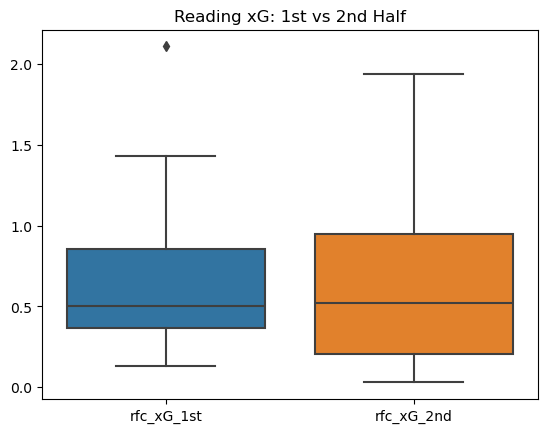

In [28]:
plt.figure()
sns.boxplot(data=richardson_df[["rfc_xG_1st", "rfc_xG_2nd"]])
plt.title("Reading xG: 1st vs 2nd Half")
plt.show()

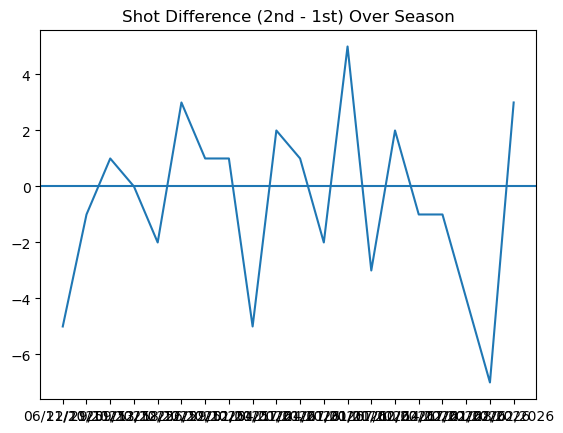

In [31]:
plt.figure()
plt.plot(richardson_df["Date"], richardson_df["rfc_Shots_Diff"])
plt.axhline(0)
plt.title("Shot Difference (2nd - 1st) Over Season")
plt.show()

In [32]:
richardson_df["Shot_Conversion_1st"] = richardson_df["rfc_HT_Score"] / richardson_df["rfc_Shots_1st"]
richardson_df["Shot_Conversion_2nd"] = (richardson_df["rfc_Score"] - richardson_df["rfc_HT_Score"]) / richardson_df["rfc_Shots_2nd"]

richardson_df[["Shot_Conversion_1st", "Shot_Conversion_2nd"]].mean()

C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\1451028871.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df["Shot_Conversion_1st"] = richardson_df["rfc_HT_Score"] / richardson_df["rfc_Shots_1st"]
C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\1451028871.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df["Shot_Conversion_2nd"] = (richardson_df["rfc_Score"] - richardson_df["rfc_HT_Score"]) / richardson_df["rfc_Shots_2nd"]


Shot_Conversion_1st    0.199782
Shot_Conversion_2nd    0.176369
dtype: float64

In [33]:
richardson_df["Defensive_Drop_xG"] = richardson_df["opp_xG_2nd"] - richardson_df["opp_xG_1st"]
richardson_df["Defensive_Drop_Shots"] = richardson_df["opp_Shots_2nd"] - richardson_df["opp_Shots_1st"]

richardson_df[["Defensive_Drop_xG", "Defensive_Drop_Shots"]].mean()

C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\2170361560.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df["Defensive_Drop_xG"] = richardson_df["opp_xG_2nd"] - richardson_df["opp_xG_1st"]
C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\2170361560.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df["Defensive_Drop_Shots"] = richardson_df["opp_Shots_2nd"] - richardson_df["opp_Shots_1st"]


Defensive_Drop_xG       0.2355
Defensive_Drop_Shots    2.1000
dtype: float64

In [34]:
richardson_df.groupby("Venue")[[
    "rfc_xG_Diff",
    "rfc_Shots_Diff",
    "xG_Diff_2nd"
]].mean()

,rfc_xG_Diff,rfc_Shots_Diff,xG_Diff_2nd
Venue,,,
A,-0.127778,-0.777778,-0.428889
H,-0.066364,-0.454545,0.090909


In [35]:
richardson_df.groupby("Manager")[[
    "rfc_xG_Diff",
    "rfc_Shots_Diff",
    "Defensive_Drop_xG"
]].mean().sort_values("rfc_xG_Diff", ascending=False)

,rfc_xG_Diff,rfc_Shots_Diff,Defensive_Drop_xG
Manager,,,
Leam Richardson,-0.094,-0.6,0.2355


In [36]:
richardson_df["Control_1st"] = (
    richardson_df["rfc_Possession_1st"] +
    richardson_df["rfc_Passes_In_Final_Third_1st"] +
    richardson_df["rfc_Touches_In_Opp_Box_1st"]
)

richardson_df["Control_2nd"] = (
    richardson_df["rfc_Possession_2nd"] +
    richardson_df["rfc_Passes_In_Final_Third_2nd"] +
    richardson_df["rfc_Touches_In_Opp_Box_2nd"]
)

richardson_df["Control_Diff"] = richardson_df["Control_2nd"] - richardson_df["Control_1st"]

richardson_df["Control_Diff"].mean()

C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\3194866336.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df["Control_1st"] = (
C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\3194866336.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df["Control_2nd"] = (
C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\3194866336.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all column

-15.15

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split

# --- Load ---
df = pd.read_csv('../../../../data/rfc_matchdata.csv')
df = df.sort_values(["Date", "Round"]).reset_index(drop=True)
richardson_df = df[df["Manager"] == "Leam Richardson"].copy()

# --- Fix known naming inconsistencies (safe renames if present) ---
rename_map = {
    "rfc_Possesion": "rfc_Possession",
    "opp_Possesion": "opp_Possession",
    "opp_Passes_In_Finals_Third_2nd": "opp_Passes_In_Final_Third_2nd",
}
richardson_df = richardson_df.rename(columns={k: v for k, v in rename_map.items() if k in richardson_df.columns})

# --- Helper: safely get a column (returns NaNs if missing) ---
def col(name):
    return richardson_df[name] if name in richardson_df.columns else pd.Series(np.nan, index=df.index)

# --- Coerce numeric where possible ---
for c in richardson_df.columns:
    if c not in ["Opponent", "Manager", "Result", "Venue", "Date"]:
        richardson_df[c] = pd.to_numeric(richardson_df[c], errors="ignore")

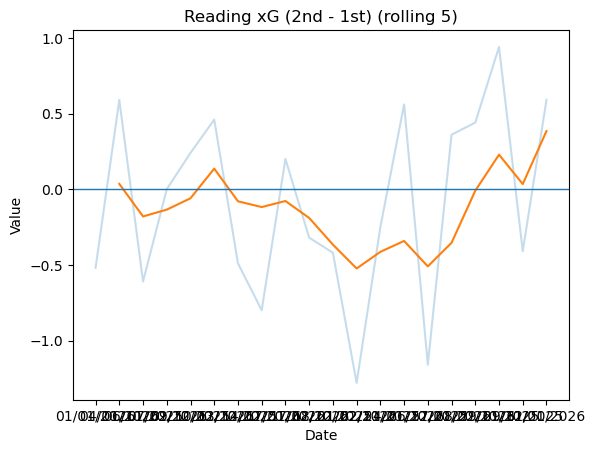

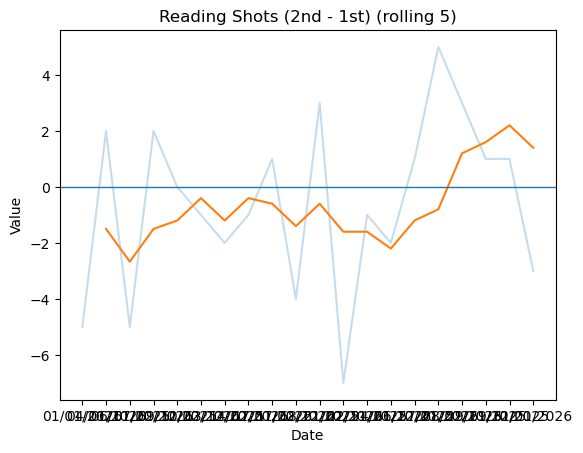

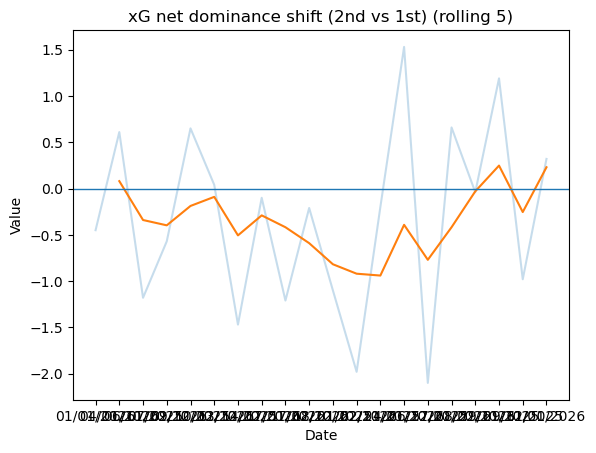

In [40]:
KEY = ["xG", "Shots", "SOT", "BigChances", "Possession", "Pass%", "Touches_In_Opp_Box"]

def add_half_diffs(prefix, metrics):
    for m in metrics:
        richardson_df[f"{prefix}_{m}_Diff"] = col(f"{prefix}_{m}_2nd") - col(f"{prefix}_{m}_1st")

add_half_diffs("rfc", KEY)
add_half_diffs("opp", KEY)

# Net (Reading minus Opponent) per half and net shift
richardson_df["xG_net_1st"] = col("rfc_xG_1st") - col("opp_xG_1st")
richardson_df["xG_net_2nd"] = col("rfc_xG_2nd") - col("opp_xG_2nd")
richardson_df["xG_net_shift"] = richardson_df["xG_net_2nd"] - richardson_df["xG_net_1st"]

def plot_rolling(series, title, window=5):
    r = series.rolling(window, min_periods=max(2, window//2)).mean()
    plt.figure()
    plt.plot(richardson_df["Date"], series, alpha=0.25)
    plt.plot(richardson_df["Date"], r)
    plt.axhline(0, linewidth=1)
    plt.title(f"{title} (rolling {window})")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.show()

# Momentum charts
plot_rolling(richardson_df["rfc_xG_Diff"], "Reading xG (2nd - 1st)", window=5)
plot_rolling(richardson_df["rfc_Shots_Diff"], "Reading Shots (2nd - 1st)", window=5)
plot_rolling(richardson_df["xG_net_shift"], "xG net dominance shift (2nd vs 1st)", window=5)

In [41]:
# Features you can expand/trim
cluster_feats = [
    "rfc_xG_Diff", "rfc_Shots_Diff", "rfc_SOT_Diff", "rfc_BigChances_Diff",
    "rfc_Possession_Diff", "rfc_Pass%_Diff", "rfc_Touches_In_Opp_Box_Diff",
    "opp_xG_Diff", "opp_Shots_Diff", "opp_SOT_Diff",
    "xG_net_shift"
]

X = richardson_df[cluster_feats].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.mean(numeric_only=True))

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Pick K by silhouette
scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(Xs)
    scores[k] = silhouette_score(Xs, labels)

best_k = max(scores, key=scores.get)
print("Silhouette scores:", scores)
print("Best K:", best_k)

km = KMeans(n_clusters=best_k, n_init=50, random_state=42)
richardson_df["HalfProfileCluster"] = km.fit_predict(Xs)

# Cluster summaries
cluster_summary = richardson_df.groupby("HalfProfileCluster")[cluster_feats].mean().round(3)
print(cluster_summary)

# Optional: quick look at results by cluster
print(richardson_df.groupby("HalfProfileCluster")["Result"].value_counts(normalize=True).round(3))

c:\Users\arbry\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\arbry\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\arbry\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\arbry\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

Silhouette scores: {2: 0.20493320008312269, 3: 0.17038397337741756, 4: 0.16301308806160764, 5: 0.15423205809487625, 6: 0.1436884306383794, 7: 0.15487843329276146}
Best K: 2


c:\Users\arbry\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


                    rfc_xG_Diff  rfc_Shots_Diff  rfc_SOT_Diff  rfc_BigChances_Diff  rfc_Possession_Diff  rfc_Pass%_Diff  rfc_Touches_In_Opp_Box_Diff  opp_xG_Diff  opp_Shots_Diff  opp_SOT_Diff  xG_net_shift
HalfProfileCluster                                                                                                                                                                                           
0                         0.254           0.846         1.462                0.308               -3.154          -4.000                       -2.077        0.185           1.846         1.462         0.069
1                        -0.740          -3.286        -1.714               -1.429              -11.000          -7.429                       -4.429        0.330           2.571         1.286        -1.070
HalfProfileCluster  Result
0                   W         0.462
                    D         0.308
                    L         0.231
1                   W         0.571
     

C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\1221162794.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df["HalfProfileCluster"] = km.fit_predict(Xs)


C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\1189639508.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df["CollapseIndex"] = Z.mean(axis=1)


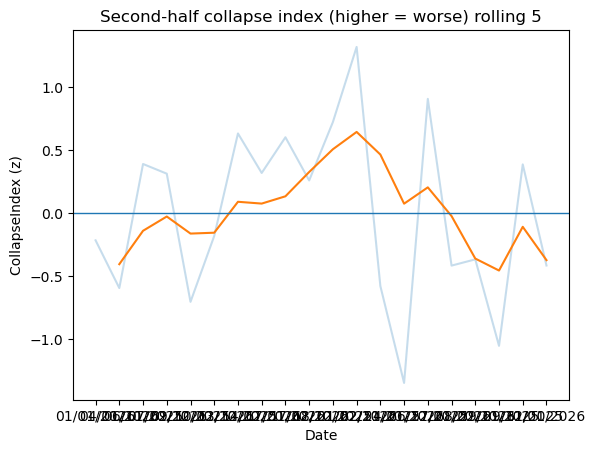

      Date      Opponent Venue Result  rfc_HT_Score  opp_HT_Score  rfc_Score  opp_Score  CollapseIndex
21/02/2026     Port Vale     A      D             1             0          1          1       1.319131
26/12/2025      Plymouth     A      W             3             0          4          1       0.907051
18/12/2025         Luton     H      W             1             0          3          2       0.723343
13/12/2025 Bradford City     A      L             0             0          0          2       0.632896
17/01/2026 Leyton Orient     A      L             0             1          1          3       0.602720
06/11/2025     Stevenage     H      W             1             0          1          0       0.390859
29/12/2025  Peterborough     A      D             1             0          1          1       0.387716
14/02/2026       Wycombe     H      W             2             0          3          2       0.319590
07/02/2026     Wimbledon     A      L             1             1        

In [43]:
# Second-half goals for/against
richardson_df["GF_2nd"] = col("rfc_Score") - col("rfc_HT_Score")
richardson_df["GA_2nd"] = col("opp_Score") - col("opp_HT_Score")

# Defensive drop and attacking drop measures
richardson_df["Concede_xG_Drop"] = col("opp_xG_2nd") - col("opp_xG_1st")
richardson_df["Attack_xG_Drop"] = col("rfc_xG_1st") - col("rfc_xG_2nd")  # positive = worse in 2nd
richardson_df["Control_Drop"] = (col("rfc_Possession_1st") - col("rfc_Possession_2nd"))
richardson_df["Net_xG_Collapse"] = richardson_df["xG_net_1st"] - richardson_df["xG_net_2nd"]  # positive = worse in 2nd

collapse_components = pd.DataFrame({
    "GA_2nd": richardson_df["GA_2nd"],
    "Concede_xG_Drop": richardson_df["Concede_xG_Drop"],
    "Attack_xG_Drop": richardson_df["Attack_xG_Drop"],
    "Control_Drop": richardson_df["Control_Drop"],
    "Net_xG_Collapse": richardson_df["Net_xG_Collapse"]
}).replace([np.inf, -np.inf], np.nan)

# Standardize components to z-scores and average
Z = (collapse_components - collapse_components.mean()) / collapse_components.std(ddof=0)
richardson_df["CollapseIndex"] = Z.mean(axis=1)

# Rolling collapse trend
plt.figure()
plt.plot(richardson_df["Date"], richardson_df["CollapseIndex"], alpha=0.25)
plt.plot(richardson_df["Date"], richardson_df["CollapseIndex"].rolling(5, min_periods=2).mean())
plt.axhline(0, linewidth=1)
plt.title("Second-half collapse index (higher = worse) rolling 5")
plt.xlabel("Date")
plt.ylabel("CollapseIndex (z)")
plt.show()

# Worst games
worst = richardson_df.sort_values("CollapseIndex", ascending=False)[
    ["Date","Opponent","Venue","Result","rfc_HT_Score","opp_HT_Score","rfc_Score","opp_Score","CollapseIndex"]
].head(10)
print(worst.to_string(index=False))

Model R^2 (in-sample): 0.49


C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\3191136081.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df["HT_Diff"] = col("rfc_HT_Score") - col("opp_HT_Score")
C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\3191136081.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df["HT_State"] = np.select(
C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\3191136081.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor

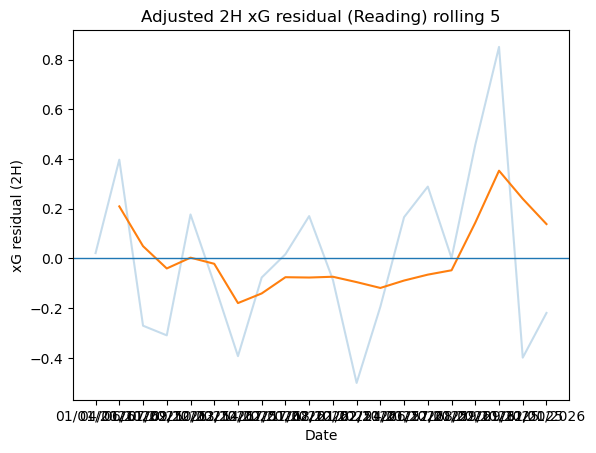

In [44]:
# HT State
richardson_df["HT_Diff"] = col("rfc_HT_Score") - col("opp_HT_Score")
richardson_df["HT_State"] = np.select(
    [richardson_df["HT_Diff"] > 0, richardson_df["HT_Diff"] < 0],
    ["Winning", "Losing"],
    default="Drawing"
)

# Opponent strength proxy: opp league position (lower is stronger). Use as numeric.
# Also include Reading league position for context if you want.
features = pd.DataFrame({
    "rfc_xG_1st": col("rfc_xG_1st"),
    "opp_league_position": col("opp_league_position"),
    "rfc_league_position": col("rfc_league_position"),
    "is_home": (col("Venue").astype(str).str.lower().str.contains("home")).astype(int)
})

# One-hot for HT state
ht_dummies = pd.get_dummies(richardson_df["HT_State"], prefix="HT", drop_first=True)
X = pd.concat([features, ht_dummies], axis=1).replace([np.inf, -np.inf], np.nan)
y = col("rfc_xG_2nd")

# Clean rows
mask = X.notna().all(axis=1) & y.notna()
Xc, yc = X.loc[mask], y.loc[mask]

lin = LinearRegression()
lin.fit(Xc, yc)

richardson_df.loc[mask, "xG2_expected"] = lin.predict(Xc)
richardson_df.loc[mask, "xG2_adjusted_resid"] = yc - richardson_df.loc[mask, "xG2_expected"]  # + = better than expected

print("Model R^2 (in-sample):", round(lin.score(Xc, yc), 3))

# Plot adjusted 2H xG residuals rolling
plt.figure()
plt.plot(richardson_df["Date"], richardson_df["xG2_adjusted_resid"], alpha=0.25)
plt.plot(richardson_df["Date"], richardson_df["xG2_adjusted_resid"].rolling(5, min_periods=2).mean())
plt.axhline(0, linewidth=1)
plt.title("Adjusted 2H xG residual (Reading) rolling 5")
plt.xlabel("Date")
plt.ylabel("xG residual (2H)")
plt.show()

HT model accuracy (test): 0.4


C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\2659549623.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df["Win"] = (col("Result").astype(str).str.upper() == "W").astype(int)
C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\2659549623.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  richardson_df.loc[mask, "Pwin_HT"] = clf.predict_proba(X)[:, 1]
C:\Users\arbry\AppData\Local\Temp\ipykernel_38808\2659549623.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

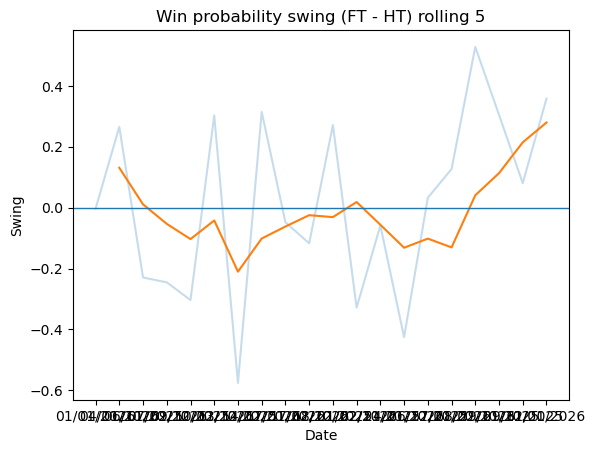

Top improvements after HT:
      Date      Opponent Venue Result  rfc_HT_Score  opp_HT_Score  rfc_Score  opp_Score  Pwin_HT  Pwin_FT  WinProbSwing
28/02/2026 Bradford City     H      W             0             0          2          1 0.233552 0.761689      0.528136
31/01/2026   Northampton     A      W             0             0          2          0 0.579507 0.937657      0.358150
14/02/2026       Wycombe     H      W             2             0          3          2 0.499096 0.813836      0.314740
29/11/2025     Blackpool     A      W             1             0          3          0 0.691892 0.996808      0.304916
10/02/2026         Wigan     A      W             0             0          2          1 0.453393 0.756318      0.302925
18/12/2025         Luton     H      W             1             0          3          2 0.490961 0.762267      0.271306
04/01/2026     Stockport     H      W             0             0          1          0 0.437308 0.702628      0.265320
27/01/2026   

In [45]:
# Define outcome
richardson_df["Win"] = (col("Result").astype(str).str.upper() == "W").astype(int)

# HT features (available at halftime)
HTX = pd.DataFrame({
    "HT_goal_diff": richardson_df["HT_Diff"],
    "HT_xG_diff": col("rfc_xG_1st") - col("opp_xG_1st"),
    "HT_shot_diff": col("rfc_Shots_1st") - col("opp_Shots_1st"),
    "is_home": (col("Venue").astype(str).str.lower().str.contains("home")).astype(int),
    "opp_league_position": col("opp_league_position"),
    "rfc_league_position": col("rfc_league_position"),
}).replace([np.inf, -np.inf], np.nan)

mask = HTX.notna().all(axis=1) & richardson_df["Win"].notna()
X, y = HTX.loc[mask], richardson_df.loc[mask, "Win"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)
print("HT model accuracy (test):", round(clf.score(X_test, y_test), 3))

richardson_df.loc[mask, "Pwin_HT"] = clf.predict_proba(X)[:, 1]

# "FT info" probability (not truly predictive; used to measure swing logically)
# Use final goal diff + total xG diff + total shots diff to compute a pseudo win probability.
FTX = pd.DataFrame({
    "FT_goal_diff": col("rfc_Score") - col("opp_Score"),
    "FT_xG_diff": col("rfc_xG") - col("opp_xG"),
    "FT_shot_diff": col("rfc_Shots") - col("opp_Shots"),
}).replace([np.inf, -np.inf], np.nan)

mask2 = FTX.notna().all(axis=1) & richardson_df["Win"].notna()

# Fit separate logistic for mapping FT margins -> win probability
clf2 = LogisticRegression(max_iter=2000)
clf2.fit(FTX.loc[mask2], richardson_df.loc[mask2, "Win"])
richardson_df.loc[mask2, "Pwin_FT"] = clf2.predict_proba(FTX.loc[mask2])[:, 1]

richardson_df["WinProbSwing"] = richardson_df["Pwin_FT"] - richardson_df["Pwin_HT"]

# Rolling swing chart
plt.figure()
plt.plot(richardson_df["Date"], richardson_df["WinProbSwing"], alpha=0.25)
plt.plot(richardson_df["Date"], richardson_df["WinProbSwing"].rolling(5, min_periods=2).mean())
plt.axhline(0, linewidth=1)
plt.title("Win probability swing (FT - HT) rolling 5")
plt.xlabel("Date")
plt.ylabel("Swing")
plt.show()

# Biggest positive / negative swings
cols_show = ["Date","Opponent","Venue","Result","rfc_HT_Score","opp_HT_Score","rfc_Score","opp_Score","Pwin_HT","Pwin_FT","WinProbSwing"]
print("Top improvements after HT:")
print(richardson_df.sort_values("WinProbSwing", ascending=False)[cols_show].head(10).to_string(index=False))
print("\nBiggest drops after HT:")
print(richardson_df.sort_values("WinProbSwing", ascending=True)[cols_show].head(10).to_string(index=False))